# 06. German & Israeli Reviewer Analysis

Examines USHMM TripAdvisor reviews from visitors located in Germany and Israel —
two groups with distinct heritage relationships to the Holocaust.
German visitors carry perpetrator-heritage; Israeli visitors carry survivor/descendant-heritage.
Both relationships are theoretically significant for transitional justice scholarship.

**Input:** `../Data/Raw/ushmm_tripadvisor_full.xlsx`  
**Input:** `../Data/Processed/ushmm_master.csv` (for semantic + sentiment columns, English only)

## Structure
1. **Descriptive analysis** — all reviews (German + non-English included)
2. **Semantic & sentiment analysis** — English-only subset

> **Important caveat:** `reviewer_location` is a *geographic* proxy, not an identity measure.
> A visitor from Berlin may not identify as German; an American Jewish visitor with strong
> Holocaust heritage would not be captured here. Findings should be interpreted as
> location-based patterns, not identity-based ones.

> **Sample sizes:** Germany n=39, Israel n=53. All findings are exploratory and descriptive.
> No significance testing is applied given small samples.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from collections import Counter

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. Load Data & Flag Groups


In [2]:
# Load full Excel (all languages)
raw = pd.read_excel('../Data/Raw/ushmm_tripadvisor_full.xlsx')

df = pd.DataFrame({
    'review_id':          raw['id'],
    'rating':             raw['rating'],
    'review_text':        raw['text'],
    'review_title':       raw['title'],
    'group_type':         raw['tripType'],
    'reviewer_location':  raw['user/userLocation/name'],
    'likes':              raw['helpfulVotes'],
    'published_date':     pd.to_datetime(raw['publishedDate']),
    'lang':               raw['lang'],
    'reviewer_contributions': raw['user/contributions/totalContributions'],
})
df['year'] = df['published_date'].dt.year
df['review_length'] = df['review_text'].astype(str).str.len()

# Flag German and Israeli reviewers (geographic proxy)
df['is_german']  = df['reviewer_location'].str.contains(
    r'Germany$|, Germany', case=False, na=False
)
df['is_israeli'] = df['reviewer_location'].str.contains(
    r'Israel$|, Israel', case=False, na=False
)

german  = df[df['is_german']].copy()
israeli = df[df['is_israeli']].copy()
overall_en = df[df['lang'] == 'en'].copy()

print(f'German reviewers (all languages):  {len(german)}')
print(f'Israeli reviewers (all languages): {len(israeli)}')
print(f'Overall English corpus:            {len(overall_en)}')
print()
print('German language breakdown:')
print(german['lang'].value_counts())
print()
print('Israeli language breakdown:')
print(israeli['lang'].value_counts())


German reviewers (all languages):  39
Israeli reviewers (all languages): 53
Overall English corpus:            10114

German language breakdown:
lang
de    22
en    16
pt     1
Name: count, dtype: int64

Israeli language breakdown:
lang
en    47
iw     5
ru     1
Name: count, dtype: int64


## 2. Rating Distributions

Using all reviews (all languages) for both groups.


In [3]:
groups = {
    'Germany\n(n=39)':  german,
    'Israel\n(n=53)':   israeli,
    'Overall EN\n(n=10,114)': overall_en,
}

print('Rating distributions:')
for label, grp in groups.items():
    counts = grp['rating'].value_counts().sort_index()
    pct_5 = (grp['rating'] == 5).mean() * 100
    print(f'\n{label.replace(chr(10), " ")}')
    print(f'  Mean: {grp["rating"].mean():.3f} | 5-star share: {pct_5:.1f}%')
    print(f'  {counts.to_dict()}')


Rating distributions:

Germany (n=39)
  Mean: 4.744 | 5-star share: 82.1%
  {3: 3, 4: 4, 5: 32}

Israel (n=53)
  Mean: 4.943 | 5-star share: 94.3%
  {4: 3, 5: 50}

Overall EN (n=10,114)
  Mean: 4.715 | 5-star share: 80.1%
  {1: 75, 2: 117, 3: 419, 4: 1397, 5: 8106}


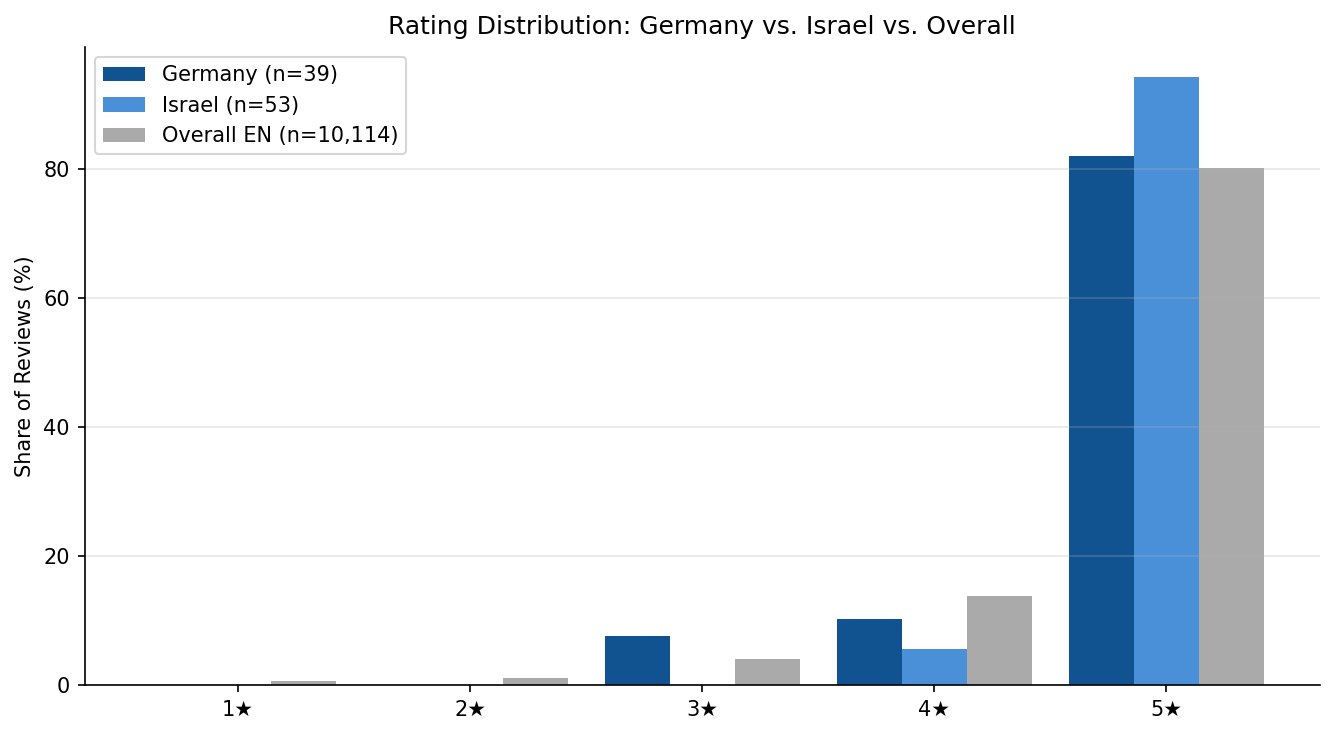

In [4]:
# Side-by-side bar chart: % of reviews per star rating
fig, ax = plt.subplots(figsize=(9, 5))

stars = [1, 2, 3, 4, 5]
x = np.arange(len(stars))
width = 0.28
colors = ['#115391', '#4a90d9', '#aaaaaa']

for idx, (label, grp) in enumerate(groups.items()):
    counts = grp['rating'].value_counts().reindex(stars, fill_value=0)
    pcts = counts / len(grp) * 100
    ax.bar(x + (idx - 1) * width, pcts.values, width,
           label=label.replace('\n', ' '), color=colors[idx])

ax.set_xticks(x)
ax.set_xticklabels([f'{s}★' for s in stars])
ax.set_ylabel('Share of Reviews (%)')
ax.set_title('Rating Distribution: Germany vs. Israel vs. Overall')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/Figures/heritage_rating_distribution.png', dpi=300)
plt.show()


## 3. Visitor Group Type


In [5]:
print('Group type breakdown:')
for label, grp in groups.items():
    print(f'\n{label.replace(chr(10), " ")}')
    gt = grp['group_type'].value_counts(normalize=True) * 100
    print(gt.round(1).to_string())


Group type breakdown:

Germany (n=39)
group_type
FAMILY      24.3
NONE        21.6
COUPLES     21.6
SOLO        13.5
FRIENDS     10.8
BUSINESS     8.1

Israel (n=53)
group_type
COUPLES     32.1
SOLO        30.2
FAMILY      17.0
NONE        11.3
BUSINESS     7.5
FRIENDS      1.9

Overall EN (n=10,114)
group_type
FAMILY      32.9
COUPLES     27.4
FRIENDS     13.7
NONE        13.4
SOLO         8.4
BUSINESS     4.2


## 4. Review Length & Temporal Pattern


In [6]:
print('Mean review length (characters):')
for label, grp in groups.items():
    print(f'  {label.replace(chr(10)," "):30s} {grp["review_length"].mean():.0f}')

print()
print('Reviews by year:')
print('Year  | Germany | Israel')
print('-' * 25)
years = sorted(set(german['year'].dropna()) | set(israeli['year'].dropna()))
for y in years:
    g_n = (german['year'] == y).sum()
    i_n = (israeli['year'] == y).sum()
    if g_n > 0 or i_n > 0:
        print(f'{int(y):5d} | {g_n:7d} | {i_n:6d}')


Mean review length (characters):
  Germany (n=39)                 368
  Israel (n=53)                  316
  Overall EN (n=10,114)          430

Reviews by year:
Year  | Germany | Israel
-------------------------
 2010 |       1 |      0
 2011 |       1 |      1
 2012 |       2 |      6
 2013 |       3 |      5
 2014 |       2 |      8
 2015 |       7 |      8
 2016 |       8 |      6
 2017 |       6 |      9
 2018 |       4 |      4
 2019 |       2 |      4
 2020 |       1 |      0
 2021 |       0 |      1
 2022 |       0 |      1
 2023 |       1 |      0
 2024 |       1 |      0


## 5. Semantic & Sentiment Analysis (English-Only)

> **Note:** Semantic categorization (wordbank pattern matching) and sentiment analysis
> (VADER and BERT) were developed and validated on English-language text only.
> Applying these tools to German or Hebrew reviews would produce unreliable results.
> The following analyses therefore use only the English-language subset:
> **Germany n=16, Israel n=47**.
> Interpret with caution given small samples.


In [7]:
# Load master CSV which has semantic + sentiment columns
master = pd.read_csv('../Data/Processed/ushmm_master.csv')

# Flag groups in master (English-only corpus)
master['is_german']  = master['reviewer_location'].str.contains(
    r'Germany$|, Germany', case=False, na=False
)
master['is_israeli'] = master['reviewer_location'].str.contains(
    r'Israel$|, Israel', case=False, na=False
)

g_en = master[master['is_german']].copy()
i_en = master[master['is_israeli']].copy()

print(f'German reviewers (English only):  {len(g_en)}')
print(f'Israeli reviewers (English only): {len(i_en)}')
print(f'Overall corpus:                   {len(master)}')


German reviewers (English only):  16
Israeli reviewers (English only): 47
Overall corpus:                   10114


### 5.1 Sentiment Scores


In [14]:
en_groups = {
    'Germany (EN, n=16)': g_en,
    'Israel (EN, n=47)':  i_en,
    'Overall (n=10,114)': master,
}

print('Mean sentiment scores:')
print(f'{"Group":<25} {"emo_vader":>10} {"eval_vader":>11} {"bert_score":>11}')
print('-' * 60)
for label, grp in en_groups.items():
    print(f'{label:<25}'
          f'{grp["emo_vader"].mean():>10.3f}'
          f'{grp["eval_vader"].mean():>11.3f}'
          f'{grp["bert_score"].mean():>11.3f}')


Mean sentiment scores:
Group                      emo_vader  eval_vader  bert_score
------------------------------------------------------------
Germany (EN, n=16)            0.360      0.446      0.876
Israel (EN, n=47)             0.108      0.390      0.789
Overall (n=10,114)            0.302      0.476      0.670


### 5.2 Memorial Paradox Rates


In [15]:
print('Sentiment quadrant distribution:')
print()
for label, grp in en_groups.items():
    total = len(grp)
    paradox = (grp['emo_eval_bucket'] == 'Emo- / Eval+').sum()
    paradox_pct = paradox / total * 100
    print(f'{label}')
    dist = grp['emo_eval_bucket'].value_counts()
    for bucket, n in dist.items():
        marker = ' ← Memorial Paradox' if bucket == 'Emo- / Eval+' else ''
        print(f'  {bucket:<20} {n:>4} ({n/total*100:.1f}%){marker}')
    print()


Sentiment quadrant distribution:

Germany (EN, n=16)
  Emo+ / Eval+           10 (62.5%)
  Mixed / Neutral         5 (31.2%)
  Emo- / Eval+            1 (6.2%) ← Memorial Paradox

Israel (EN, n=47)
  Emo+ / Eval+           25 (53.2%)
  Mixed / Neutral        20 (42.6%)
  Emo- / Eval+            2 (4.3%) ← Memorial Paradox

Overall (n=10,114)
  Emo+ / Eval+         6460 (63.9%)
  Mixed / Neutral      3075 (30.4%)
  Emo- / Eval+          342 (3.4%) ← Memorial Paradox
  Emo- / Eval-          237 (2.3%)



### 5.3 Semantic Category Profiles


In [10]:
# Parse content_cats_str back to lists
def parse_cats(s):
    if pd.isna(s) or s == '':
        return []
    return s.split('|')

for df_ in [g_en, i_en, master]:
    df_['content_cats'] = df_['content_cats_str'].apply(parse_cats)

all_cats = [
    'Learning Context (General)',
    'Reflection / Suggestions',
    'Learning / Understanding',
    'Comparison / Other Museums',
    'Motivation / Why Visit',
    'Prior Knowledge',
]

print(f'Category prevalence (% of reviews matching):')
print(f'{"Category":<30} {"Germany":>10} {"Israel":>10} {"Overall":>10}')
print('-' * 65)
for cat in all_cats:
    g_pct = g_en['content_cats'].apply(lambda x: cat in x).mean() * 100
    i_pct = i_en['content_cats'].apply(lambda x: cat in x).mean() * 100
    o_pct = master['content_cats'].apply(lambda x: cat in x).mean() * 100
    print(f'{cat:<30} {g_pct:>9.1f}% {i_pct:>9.1f}% {o_pct:>9.1f}%')


Category prevalence (% of reviews matching):
Category                          Germany     Israel    Overall
-----------------------------------------------------------------
Learning Context (General)          87.5%      76.6%      68.0%
Reflection / Suggestions            37.5%      34.0%      35.8%
Learning / Understanding            50.0%      25.5%      30.7%
Comparison / Other Museums           6.2%      12.8%       6.3%
Motivation / Why Visit               0.0%       0.0%       4.4%
Prior Knowledge                      0.0%       0.0%       1.5%


### 5.4 Qualitative Examples

Selected reviews illustrating the heritage-specific framing of German and Israeli visitors.


In [11]:
print('=== GERMAN REVIEWER EXAMPLES (English) ===')
for _, row in g_en.head(4).iterrows():
    print(f'\n★{int(row["rating"])} | {row["group_type"]} | {row["reviewer_location"]}')
    print(f'emo={row["emo_vader"]:.2f}, eval={row["eval_vader"]:.2f}, bert={row["bert_score"]:.2f}')
    print(f'{str(row["review_text"])[:400]}...')

print()
print('=== ISRAELI REVIEWER EXAMPLES (English) ===')
for _, row in i_en.head(4).iterrows():
    print(f'\n★{int(row["rating"])} | {row["group_type"]} | {row["reviewer_location"]}')
    print(f'emo={row["emo_vader"]:.2f}, eval={row["eval_vader"]:.2f}, bert={row["bert_score"]:.2f}')
    print(f'{str(row["review_text"])[:400]}...')


=== GERMAN REVIEWER EXAMPLES (English) ===

★5 | FAMILY | Heidelberg, Germany
emo=0.71, eval=0.71, bert=-0.86
We are Germans visiting this museum. Most of the facts you know from school - so not so much new information. But the presentation moved me to tears twice. When an elderly man explained the Warsaw milk cans, and at the end when some videos were shown in which a woman explained that she shared everything equally with a friend in the camp (previously a stranger, but she came to feel they were sister...

★5 | NONE | Ramstein-Miesenbach, Germany
emo=0.76, eval=0.86, bert=1.00
We often are not able to take in a perspective of a historical event, even terrible ones like the holocaust. This museum offers a unique perspective into a world event. The prisoner shoe display, as well as the children's artwork (the Nazis had them draw happy pictures) were very impacting to me. You can easily spend hours here, especially if you want to truly get a bit of understanding of the eve...

★5 | SOL

## 6. Non-English Review Examples

Raw text of German-language and Hebrew-language reviews, presented without
computational analysis. Included for completeness and to illustrate the
linguistic diversity of heritage visitors.


In [12]:
german_de = german[german['lang'] == 'de'][['rating', 'reviewer_location', 'review_text']]
print(f'German-language reviews (n={len(german_de)}):')
for _, row in german_de.head(5).iterrows():
    print(f'\n★{int(row["rating"])} | {row["reviewer_location"]}')
    print(str(row['review_text'])[:400])

print()
israeli_iw = israeli[israeli['lang'] == 'iw'][['rating', 'reviewer_location', 'review_text']]
print(f'Hebrew-language reviews (n={len(israeli_iw)}):')
for _, row in israeli_iw.iterrows():
    print(f'\n★{int(row["rating"])} | {row["reviewer_location"]}')
    print(str(row['review_text'])[:400])


German-language reviews (n=22):

★5 | Cologne, Germany
Was soll man zu einem solchen Ort bloß sagen/schreiben? Jeder, der in Washington D. C. ist, MUSS sich diese Ausstellung in all ihrer Schonungslosigkeit ansehen. Was hier an Dokumenten und Exponaten zusammengestellt wurde, bietet einen umfangreichen Einblick in das schrecklichste Verbrechen des 20. Jahrhunderts. Das darf nicht vergessen werden. Verstehen wird man es dennoch nicht.

★4 | Mainz, Germany
Sehr gut gemacht und interessant gestaltet. Zwar gratis, aber für die permanente Ausstellung muss man Karten vorbestellen, die in der Regel recht langfristig vergriffen sind. Aber auch für die Zusatz-Ausstellungen, derzeit zwei Stück, lohnt sich der Besuch.

★5 | Hamburg, Germany
Ein Museum in dem man Tage verbringen könnte. Ein Thema was sehr interessant dargestellt wird. Zudem die Art der Darstellung sehr ansprechend.

★5 | Reutlingen, Germany
Der Besuch des Museums macht einen betroffen und zeigt einem, dass so etwas nie wieder gesc

## 7. Summary


In [13]:
print('=' * 60)
print('SUMMARY')
print('=' * 60)

print('\n--- Descriptive (all languages) ---')
for label, grp, n in [('Germany', german, 39), ('Israel', israeli, 53)]:
    print(f'\n{label} (n={n})')
    print(f'  Mean rating:        {grp["rating"].mean():.3f} (overall EN: 4.715)')
    print(f'  5-star share:       {(grp["rating"]==5).mean()*100:.1f}%  (overall EN: 80.2%)')
    print(f'  Mean review length: {grp["review_length"].mean():.0f} chars (overall EN: ~430)')

print('\n--- Sentiment & Paradox (English only) ---')
for label, grp in [('Germany EN (n=16)', g_en), ('Israel EN (n=47)', i_en)]:
    paradox_pct = (grp['emo_eval_bucket'] == 'Emo- / Eval+').mean() * 100
    print(f'\n{label}')
    print(f'  BERT mean:          {grp["bert_score"].mean():.3f} (overall: 0.669)')
    print(f'  Memorial Paradox:   {paradox_pct:.1f}%   (overall: 3.4%)')


SUMMARY

--- Descriptive (all languages) ---

Germany (n=39)
  Mean rating:        4.744 (overall EN: 4.715)
  5-star share:       82.1%  (overall EN: 80.2%)
  Mean review length: 368 chars (overall EN: ~430)

Israel (n=53)
  Mean rating:        4.943 (overall EN: 4.715)
  5-star share:       94.3%  (overall EN: 80.2%)
  Mean review length: 316 chars (overall EN: ~430)

--- Sentiment & Paradox (English only) ---

Germany EN (n=16)
  BERT mean:          0.876 (overall: 0.669)
  Memorial Paradox:   6.2%   (overall: 3.4%)

Israel EN (n=47)
  BERT mean:          0.789 (overall: 0.669)
  Memorial Paradox:   4.3%   (overall: 3.4%)
